#  Procesamiento — Seguro Indexado NDVI · Caldas
**Pipeline:** ERA5 + MODIS → DataFrame unificado → QA → Filtro espacial → Split temporal

---
## Tabla de contenidos
1. [Configuración](#1-configuracion)
2. [Carga de datos ERA5](#2-era5)
3. [Carga de datos MODIS](#3-modis)
4. [Unión de datasets](#4-union)
5. [QA — Valores faltantes](#5-qa-faltantes)
6. [QA — Outliers y consistencia temporal](#6-qa-outliers)
7. [Filtro espacial: zona cafetera](#7-filtro-espacial)
8. [Split temporal Train / Val / Test](#8-split-temporal)
9. [Exportación](#9-exportacion)


## 1. Configuración

In [1]:
# !pip install rasterio pandas scipy matplotlib requests

import os
import glob
import json
import warnings
import requests
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.transform import xy
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore")


# Rutas de datos 
ERA5  = "../ERA5_Caldas"
MODIS = "../MODIS_Caldas"

# Parámetros del proyecto (
PARAMS = {
    # Zona de estudio
    "lon_min": -76.2, "lat_min": 4.7,
    "lon_max": -74.9, "lat_max": 5.7,

    # Zona cafetera Caldas (msnm)
    "elev_cafe_min": 600,
    "elev_cafe_max": 2000,

    # Umbral para excluir píxeles con exceso de nulos NDVI
    "umbral_nulos_pixel": 70,   

    # Split temporal
    "train_end": "2018-12-31",
    "val_start": "2019-01-01",
    "val_end":   "2021-12-31",
    "test_start": "2022-01-01",
}

print("Configuración cargada")
print(json.dumps(PARAMS, indent=2))


Configuración cargada
{
  "lon_min": -76.2,
  "lat_min": 4.7,
  "lon_max": -74.9,
  "lat_max": 5.7,
  "elev_cafe_min": 600,
  "elev_cafe_max": 2000,
  "umbral_nulos_pixel": 70,
  "train_end": "2018-12-31",
  "val_start": "2019-01-01",
  "val_end": "2021-12-31",
  "test_start": "2022-01-01"
}


## 2. Carga de datos ERA5

In [2]:
nombres_bandas = [
    'tmax', 'tmin', 'skin_temp', 'ppt', 'srad',
    'pet', 'soil_water', 'vap', 'vpd', 'ws', 'surface_pressure'
]

registros_era5 = []

for archivo in sorted(glob.glob(os.path.join(ERA5, "*.tif"))):
    nombre = os.path.basename(archivo)
    fecha  = nombre.replace("ERA5_Caldas_", "").replace(".tif", "")

    with rasterio.open(archivo) as src:
        transform = src.transform
        height, width = src.height, src.width
        datos = src.read()   

        filas, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
        lons, lats  = xy(transform, filas.ravel(), cols.ravel())

        for idx in range(len(lats)):
            registro = {
                'fecha': pd.to_datetime(fecha),
                'lat'  : round(lats[idx], 4),
                'lon'  : round(lons[idx], 4),
            }
            for b, nb_name in enumerate(nombres_bandas):
                registro[nb_name] = float(datos[b].ravel()[idx])
            registros_era5.append(registro)

df_era5 = pd.DataFrame(registros_era5)
df_era5 = df_era5.sort_values(['fecha', 'lat', 'lon']).reset_index(drop=True)

print(f"Shape ERA5      : {df_era5.shape}")
print(f"Fechas únicas   : {df_era5['fecha'].nunique()}")
print(f"Píxeles únicos  : {df_era5.groupby(['lat','lon']).ngroups}")
print(f"Rango temporal  : {df_era5['fecha'].min().date()} → {df_era5['fecha'].max().date()}")
df_era5.head()


Shape ERA5      : (81928, 14)
Fechas únicas   : 532
Píxeles únicos  : 154
Rango temporal  : 2003-01-01 → 2026-04-06


,fecha,lat,lon,tmax,tmin,skin_temp,ppt,srad,pet,soil_water,vap,vpd,ws,surface_pressure
0,2003-01-01,4.65,-76.1503,23.614145,15.919840,19.554695,0.057805,236048528.0,52.230103,0.470917,1.932430,0.359391,0.738607,83250.703125
1,2003-01-01,4.65,-76.0503,25.487192,17.589762,21.024364,0.036940,253406432.0,52.445595,0.362209,2.108186,0.446483,0.566873,86797.671875
2,2003-01-01,4.65,-75.9503,27.559229,18.972559,23.282244,0.021368,270922976.0,48.823105,0.342014,2.282242,0.531764,0.392410,90075.539062
3,2003-01-01,4.65,-75.8503,26.709620,17.563288,21.514681,0.030356,285098240.0,52.340019,0.353624,2.091338,0.513219,0.249482,87566.921875
4,2003-01-01,4.65,-75.7503,24.381495,14.106928,19.057995,0.085306,294679648.0,52.683231,0.398832,1.834349,0.394572,0.266291,83916.867188


## 3. Carga de datos MODIS

In [3]:
registros_modis = []

for archivo in sorted(glob.glob(os.path.join(MODIS, "*.tif"))):
    nombre = os.path.basename(archivo)
    fecha  = nombre.replace("MODIS_NDVI_Caldas_", "").replace(".tif", "")

    with rasterio.open(archivo) as src:
        transform = src.transform
        height, width = src.height, src.width
        datos = src.read(1)   # una sola banda: NDVI

        filas, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
        lons, lats  = xy(transform, filas.ravel(), cols.ravel())

        for idx in range(len(lats)):
            registros_modis.append({
                "fecha": pd.to_datetime(fecha),
                "lat"  : round(lats[idx], 4),
                "lon"  : round(lons[idx], 4),
                "NDVI" : float(datos.ravel()[idx])
            })

df_modis = pd.DataFrame(registros_modis)
df_modis = df_modis.sort_values(["fecha", "lat", "lon"]).reset_index(drop=True)

print(f"Shape MODIS    : {df_modis.shape}")
print(f"Fechas únicas  : {df_modis['fecha'].nunique()}")
print(f"Rango temporal : {df_modis['fecha'].min().date()} → {df_modis['fecha'].max().date()}")
df_modis.head()


Shape MODIS    : (81774, 4)
Fechas únicas  : 531
Rango temporal : 2003-01-01 → 2026-03-21


,fecha,lat,lon,NDVI
0,2003-01-01,4.65,-76.1503,NaN
1,2003-01-01,4.65,-76.0503,0.637604
2,2003-01-01,4.65,-75.9503,0.651808
3,2003-01-01,4.65,-75.8503,0.752173
4,2003-01-01,4.65,-75.7503,NaN


## 4. Unión ERA5 + MODIS

In [4]:
df_final = pd.merge(
    df_era5,
    df_modis,
    on=["fecha", "lat", "lon"],
    how="left"   
)

print(f"Shape final  : {df_final.shape}")
print(f"Columnas     : {list(df_final.columns)}")
print(f"NaN en NDVI  : {df_final['NDVI'].isna().sum()} ({df_final['NDVI'].isna().mean()*100:.1f}%)")
df_final.head()


Shape final  : (81928, 15)
Columnas     : ['fecha', 'lat', 'lon', 'tmax', 'tmin', 'skin_temp', 'ppt', 'srad', 'pet', 'soil_water', 'vap', 'vpd', 'ws', 'surface_pressure', 'NDVI']
NaN en NDVI  : 57944 (70.7%)


,fecha,lat,lon,tmax,tmin,skin_temp,ppt,srad,pet,soil_water,vap,vpd,ws,surface_pressure,NDVI
0,2003-01-01,4.65,-76.1503,23.614145,15.919840,19.554695,0.057805,236048528.0,52.230103,0.470917,1.932430,0.359391,0.738607,83250.703125,NaN
1,2003-01-01,4.65,-76.0503,25.487192,17.589762,21.024364,0.036940,253406432.0,52.445595,0.362209,2.108186,0.446483,0.566873,86797.671875,0.637604
2,2003-01-01,4.65,-75.9503,27.559229,18.972559,23.282244,0.021368,270922976.0,48.823105,0.342014,2.282242,0.531764,0.392410,90075.539062,0.651808
3,2003-01-01,4.65,-75.8503,26.709620,17.563288,21.514681,0.030356,285098240.0,52.340019,0.353624,2.091338,0.513219,0.249482,87566.921875,0.752173
4,2003-01-01,4.65,-75.7503,24.381495,14.106928,19.057995,0.085306,294679648.0,52.683231,0.398832,1.834349,0.394572,0.266291,83916.867188,NaN


## 5. QA — Valores faltantes
Revisamos faltantes a tres niveles: **global**, **por fecha** y **por píxel**.


In [5]:
# 5.1 Resumen global de faltantes 
resumen_faltantes = pd.DataFrame({
    "faltantes" : df_final.isna().sum(),
    "porcentaje": (df_final.isna().mean() * 100).round(2)
}).sort_values("porcentaje", ascending=False)

print("=== FALTANTES GLOBALES ===")
print(resumen_faltantes[resumen_faltantes["faltantes"] > 0].to_string())


=== FALTANTES GLOBALES ===
      faltantes  porcentaje
NDVI      57944       70.73


In [6]:
# 5.2 Faltantes NDVI por fecha 
faltantes_fecha = (
    df_final.groupby("fecha")["NDVI"]
    .agg(
        total_registros="size",
        faltantes=lambda x: x.isna().sum(),
        porcentaje_faltantes=lambda x: x.isna().mean() * 100
    )
    .reset_index()
    .sort_values("porcentaje_faltantes", ascending=False)
    .reset_index(drop=True)
)

print("=== DISTRIBUCIÓN DE FALTANTES POR UMBRAL (fechas) ===")
for u in [100, 80, 60, 40, 20]:
    n   = (faltantes_fecha["porcentaje_faltantes"] >= u).sum()
    pct = n / len(faltantes_fecha) * 100
    print(f"  >= {u:3d}% faltantes: {n:4d} fechas ({pct:.1f}%)")
print(f"\n  Total períodos: {len(faltantes_fecha)}")

# Fechas con >= 80% faltantes
fechas_criticas = faltantes_fecha[faltantes_fecha["porcentaje_faltantes"] >= 80]
print(f"\nFechas con >= 80% NDVI faltante: {len(fechas_criticas)}")
fechas_criticas.head(10)


=== DISTRIBUCIÓN DE FALTANTES POR UMBRAL (fechas) ===
  >= 100% faltantes:    7 fechas (1.3%)
  >=  80% faltantes:  229 fechas (43.0%)
  >=  60% faltantes:  374 fechas (70.3%)
  >=  40% faltantes:  471 fechas (88.5%)
  >=  20% faltantes:  521 fechas (97.9%)

  Total períodos: 532

Fechas con >= 80% NDVI faltante: 229


,fecha,total_registros,faltantes,porcentaje_faltantes
0,2026-04-06,154,154,100.000000
1,2016-02-06,154,154,100.000000
2,2015-03-07,154,154,100.000000
3,2021-02-19,154,154,100.000000
4,2022-04-27,154,154,100.000000
5,2006-02-26,154,154,100.000000
6,2011-11-23,154,154,100.000000
7,2013-04-02,154,153,99.350649
8,2013-11-12,154,153,99.350649
9,2022-03-26,154,153,99.350649


In [7]:
# 5.3 Faltantes NDVI por píxel 
nulos_por_pixel = (
    df_final.groupby(["lat", "lon"])["NDVI"]
    .agg(
        total_registros="size",
        faltantes=lambda x: x.isna().sum(),
        porcentaje_faltantes=lambda x: x.isna().mean() * 100
    )
    .reset_index()
    .sort_values("porcentaje_faltantes", ascending=False)
    .reset_index(drop=True)
)

print(f"Total píxeles: {len(nulos_por_pixel)}")
print("\nDistribución de nulos por píxel:")
for u in [100, 90, 80, 60]:
    n = (nulos_por_pixel["porcentaje_faltantes"] >= u).sum()
    print(f"  >= {u:3d}% faltantes: {n:4d} píxeles ({n/len(nulos_por_pixel)*100:.1f}%)")

nulos_por_pixel.head(10)


Total píxeles: 154

Distribución de nulos por píxel:
  >= 100% faltantes:    0 píxeles (0.0%)
  >=  90% faltantes:   27 píxeles (17.5%)
  >=  80% faltantes:   69 píxeles (44.8%)
  >=  60% faltantes:  113 píxeles (73.4%)


,lat,lon,total_registros,faltantes,porcentaje_faltantes
0,5.25,-76.1503,532,527,99.060150
1,5.65,-76.1503,532,524,98.496241
2,5.15,-76.1503,532,522,98.120301
3,5.65,-76.0503,532,522,98.120301
4,5.55,-76.0503,532,517,97.180451
5,4.75,-75.5503,532,514,96.616541
6,4.85,-75.5503,532,512,96.240602
7,4.65,-75.3503,532,509,95.676692
8,5.15,-76.0503,532,508,95.488722
9,5.05,-76.1503,532,503,94.548872


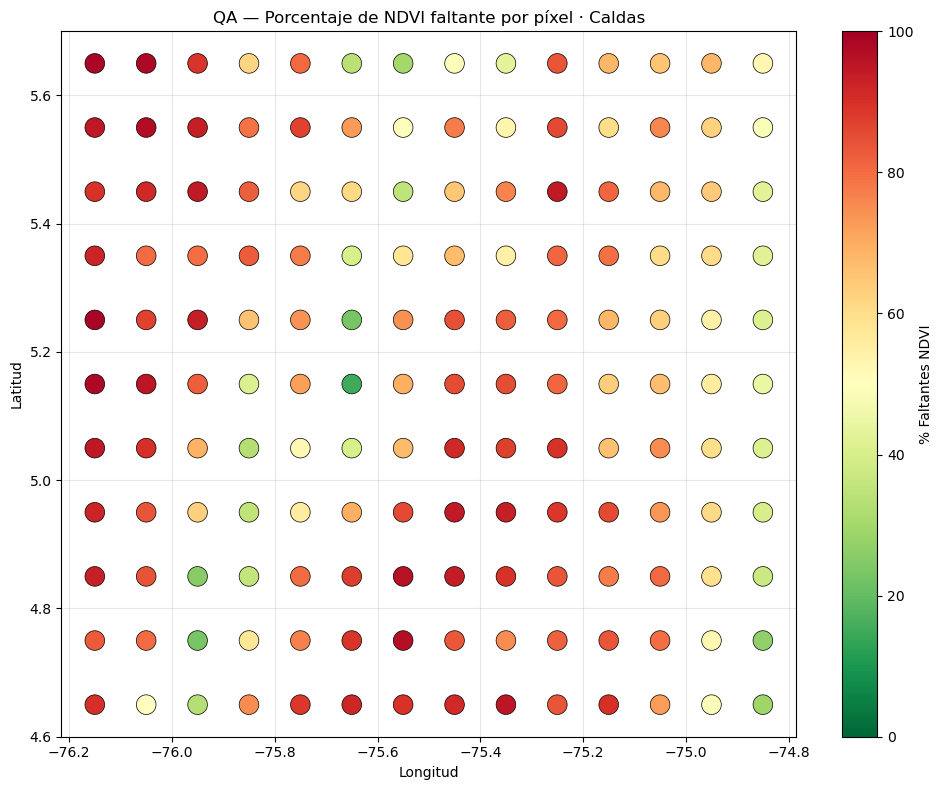

In [8]:
# 5.4 Mapa de faltantes por píxel 
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    nulos_por_pixel["lon"], nulos_por_pixel["lat"],
    c=nulos_por_pixel["porcentaje_faltantes"],
    cmap="RdYlGn_r", s=200, edgecolors="black", linewidths=0.5,
    vmin=0, vmax=100
)
plt.colorbar(scatter, ax=ax, label="% Faltantes NDVI")
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("QA — Porcentaje de NDVI faltante por píxel · Caldas")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 6. QA — Outliers y consistencia temporal
Verificamos rangos físicamente plausibles para NDVI y variables climáticas,
y comprobamos que no haya saltos bruscos (gaps) en la serie temporal.


In [9]:
# 6.1 Rangos esperados por variable 
rangos_esperados = {
    "NDVI"            : (-0.2, 1.0),
    "tmax"            : (5,    45),
    "tmin"            : (-5,   30),
    "skin_temp"       : (0,    50),
    "ppt"             : (0,    500),
    "srad"            : (0,    400),
    "pet"             : (0,    15),
    "soil_water"      : (0,    1),
    "vap"             : (0,    5),
    "vpd"             : (0,    5),
    "ws"              : (0,    20),
    "surface_pressure": (50000, 110000),
}

print("=== OUTLIERS POR VARIABLE ===\n")
outliers_resumen = []
for col, (vmin, vmax) in rangos_esperados.items():
    if col not in df_final.columns:
        continue
    serie = df_final[col].dropna()
    n_out = ((serie < vmin) | (serie > vmax)).sum()
    pct   = n_out / len(serie) * 100
    outliers_resumen.append({
        "variable": col, "min_obs": serie.min(), "max_obs": serie.max(),
        "rango_esperado": f"[{vmin}, {vmax}]",
        "outliers": n_out, "pct_outliers": round(pct, 3)
    })
    if n_out > 0:
        print(f"  ⚠️  {col}: {n_out} outliers ({pct:.2f}%) | obs=[{serie.min():.2f}, {serie.max():.2f}]")
    else:
        print(f"  ✅ {col}: OK | obs=[{serie.min():.2f}, {serie.max():.2f}]")

df_outliers = pd.DataFrame(outliers_resumen)


=== OUTLIERS POR VARIABLE ===

  ✅ NDVI: OK | obs=[0.33, 0.91]
  ✅ tmax: OK | obs=[11.32, 39.71]
  ✅ tmin: OK | obs=[0.28, 23.23]
  ✅ skin_temp: OK | obs=[7.14, 28.30]
  ✅ ppt: OK | obs=[0.00, 2.16]
  ⚠️  srad: 81928 outliers (100.00%) | obs=[99988312.00, 401747776.00]
  ⚠️  pet: 81928 outliers (100.00%) | obs=[16.32, 88.53]
  ✅ soil_water: OK | obs=[0.13, 0.50]
  ✅ vap: OK | obs=[0.68, 2.80]
  ✅ vpd: OK | obs=[0.10, 2.77]
  ✅ ws: OK | obs=[0.07, 1.88]
  ✅ surface_pressure: OK | obs=[64752.03, 97012.46]


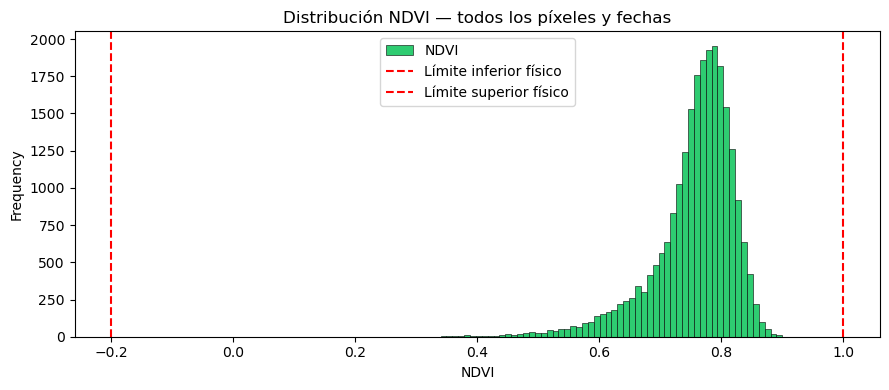

In [10]:
#  6.2 Distribución NDVI (histograma)
fig, ax = plt.subplots(figsize=(9, 4))
df_final["NDVI"].dropna().plot.hist(bins=60, ax=ax, color="#2ECC71", edgecolor="black", linewidth=0.4)
ax.axvline(-0.2, color="red",  linestyle="--", label="Límite inferior físico")
ax.axvline(1.0,  color="red",  linestyle="--", label="Límite superior físico")
ax.set_xlabel("NDVI"); ax.set_title("Distribución NDVI — todos los píxeles y fechas")
ax.legend(); plt.tight_layout(); plt.show()


In [11]:
# 6.3 Consistencia temporal — gaps en la serie 
fechas_unicas = df_final["fecha"].drop_duplicates().sort_values().reset_index(drop=True)
deltas = fechas_unicas.diff().dropna()

print(f"Rango temporal : {fechas_unicas.min().date()} → {fechas_unicas.max().date()}")
print(f"Total períodos : {len(fechas_unicas)}")
print(f"\nEspaciado entre fechas:")
print(deltas.value_counts().rename_axis("delta").reset_index(name="frecuencia").to_string(index=False))

gaps = deltas[deltas > pd.Timedelta(days=32)]
if len(gaps) > 0:
    print(f"\n Gaps > 32 días detectados: {len(gaps)}")
    print(gaps.reset_index())
else:
    print("\n No hay gaps mayores a 32 días en la serie temporal.")


Rango temporal : 2003-01-01 → 2026-04-06
Total períodos : 532

Espaciado entre fechas:
  delta  frecuencia
16 days         531

 No hay gaps mayores a 32 días en la serie temporal.


=== COBERTURA NDVI POR AÑO ===
 anio  total  no_nulos  pct_cobertura
 2003   3542      1069      30.180689
 2004   3542      1131      31.931112
 2005   3542       978      27.611519
 2006   3542      1016      28.684359
 2007   3542      1046      29.531338
 2008   3388       651      19.214876
 2009   3542      1092      30.830040
 2010   3542       824      23.263693
 2011   3542       752      21.230943
 2012   3542      1338      37.775268
 2013   3542       939      26.510446
 2014   3388      1072      31.641086
 2015   3542      1471      41.530209
 2016   3542      1106      31.225296
 2017   3542       975      27.526821
 2018   3542      1284      36.250706
 2019   3542      1068      30.152456
 2020   3388       939      27.715466
 2021   3542       702      19.819311
 2022   3542       438      12.365895
 2023   3542      1447      40.852626
 2024   3542      1383      39.045737
 2025   3542       995      28.091474
 2026    924       268      29.004329


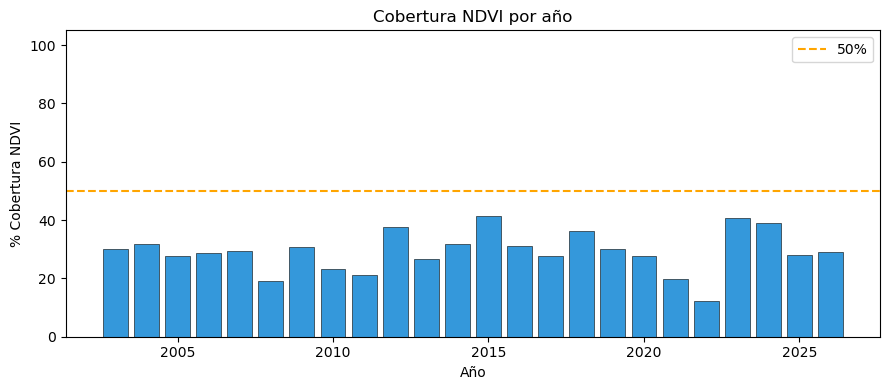

In [12]:
# 6.4 Cobertura de NDVI por año 
cobertura_anual = (
    df_final.assign(anio=df_final["fecha"].dt.year)
    .groupby("anio")["NDVI"]
    .agg(
        total="size",
        no_nulos=lambda x: x.notna().sum(),
        pct_cobertura=lambda x: x.notna().mean() * 100
    )
    .reset_index()
)

print("=== COBERTURA NDVI POR AÑO ===")
print(cobertura_anual.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cobertura_anual["anio"], cobertura_anual["pct_cobertura"], color="#3498DB", edgecolor="black", linewidth=0.4)
ax.set_ylim(0, 105)
ax.set_xlabel("Año"); ax.set_ylabel("% Cobertura NDVI")
ax.set_title("Cobertura NDVI por año")
ax.axhline(50, color="orange", linestyle="--", label="50%")
ax.legend(); plt.tight_layout(); plt.show()


=== COBERTURA NDVI POR MES (dataset completo) ===
Mes       Total  Válidos   % válido  Barra
──────────────────────────────────────────────────────────
Ene       7,084    2,405      33.9%  ██████
Feb       6,468    1,521      23.5%  ████
Mar       7,392    1,254      17.0%  ███  ⚠️
Abr       6,622    1,091      16.5%  ███  ⚠️
May       6,930    2,021      29.2%  █████
Jun       6,622    2,728      41.2%  ████████
Jul       6,930    3,438      49.6%  █████████
Ago       6,776    3,088      45.6%  █████████
Sep       6,622    1,858      28.1%  █████
Oct       6,776    1,107      16.3%  ███  ⚠️
Nov       6,776    1,306      19.3%  ███  ⚠️
Dic       6,930    2,167      31.3%  ██████


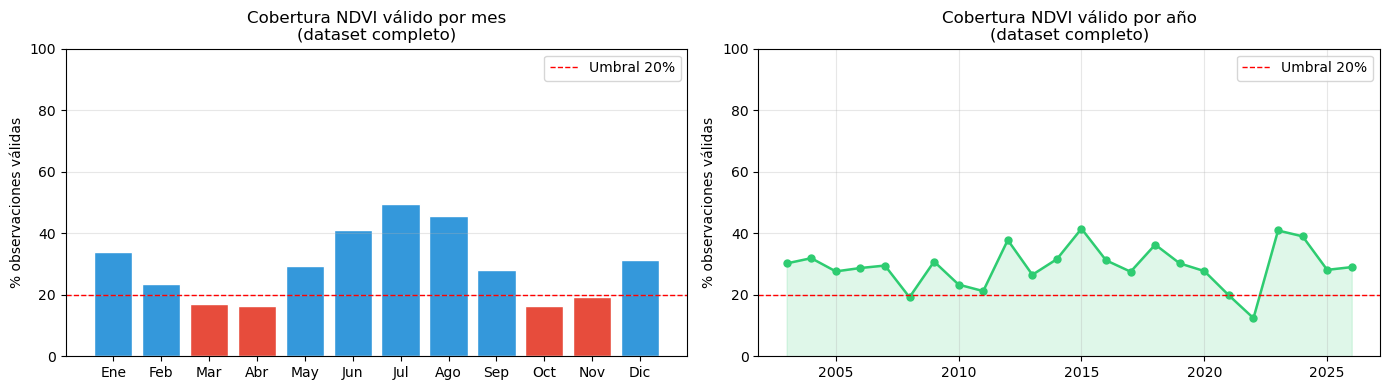


Meses con < 20% cobertura NDVI: 4
  Mar, Abr, Oct, Nov

Implicación: en estos meses las métricas R4, R5 tendrán
menor respaldo estadístico. Se documenta como limitación.


In [13]:
# =====================================================================

# 6.5  Cobertura NDVI por mes — estacionalidad de los faltantes

#

# Se evalúa sobre df_final (dataset completo, sin filtros espaciales

# ni particiones temporales) para el diagnóstico más representativo.

#

# Responde a: ¿los faltantes se concentran en ciertos meses del año

# (épocas de mayor nubosidad) o están distribuidos uniformemente?

# =====================================================================
 
NOMBRES_MES = {

    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',

    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'

}
 
cobertura_mes = (

    df_final

    .assign(mes=df_final['fecha'].dt.month)

    .groupby('mes')['NDVI']

    .agg(

        n_total  = 'size',                          # total filas, incluye NaN

        n_valido = lambda x: x.notna().sum()        # solo valores válidos

    )

    .assign(

        pct_valido = lambda d: (d['n_valido'] / d['n_total'] * 100).round(1),

        mes_nombre = lambda d: d.index.map(NOMBRES_MES)

    )

)
 
print('=== COBERTURA NDVI POR MES (dataset completo) ===')

print(f'{"Mes":<6} {"Total":>8} {"Válidos":>8} {"% válido":>10}  Barra')

print('─' * 58)

for _, row in cobertura_mes.iterrows():

    barra  = '█' * int(row['pct_valido'] / 5)

    alerta = '  ⚠️' if row['pct_valido'] < 20 else ''

    print(f"{row['mes_nombre']:<6} {int(row['n_total']):>8,} "

          f"{int(row['n_valido']):>8,} {row['pct_valido']:>9.1f}%  "

          f"{barra}{alerta}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Panel izquierdo: cobertura por mes

colores_mes = ['#E74C3C' if v < 20 else '#3498DB'

               for v in cobertura_mes['pct_valido']]

axes[0].bar(cobertura_mes['mes_nombre'],

            cobertura_mes['pct_valido'],

            color=colores_mes, edgecolor='white')

axes[0].axhline(20, color='red', linestyle='--',

                linewidth=1, label='Umbral 20%')

axes[0].set_title('Cobertura NDVI válido por mes\n(dataset completo)')

axes[0].set_ylabel('% observaciones válidas')

axes[0].set_ylim(0, 100)

axes[0].legend()

axes[0].grid(True, alpha=0.3, axis='y')
 
# Panel derecho: cobertura por año

cob_anual = (

    df_final

    .assign(anio=df_final['fecha'].dt.year)

    .groupby('anio')['NDVI']

    .agg(

        n_total  = 'size',                          # total filas, incluye NaN

        n_valido = lambda x: x.notna().sum()

    )

    .assign(pct_valido = lambda d: (d['n_valido'] / d['n_total'] * 100).round(1))

)

axes[1].plot(cob_anual.index, cob_anual['pct_valido'],

             marker='o', color='#2ECC71', linewidth=1.8, markersize=5)

axes[1].axhline(20, color='red', linestyle='--',

                linewidth=1, label='Umbral 20%')

axes[1].fill_between(cob_anual.index, cob_anual['pct_valido'],

                     alpha=0.15, color='#2ECC71')

axes[1].set_title('Cobertura NDVI válido por año\n(dataset completo)')

axes[1].set_ylabel('% observaciones válidas')

axes[1].set_ylim(0, 100)

axes[1].legend()

axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()

plt.show()
 
meses_criticos = cobertura_mes[cobertura_mes['pct_valido'] < 20]

print(f'\nMeses con < 20% cobertura NDVI: {len(meses_criticos)}')

if len(meses_criticos) > 0:

    print('  ' + ', '.join(meses_criticos['mes_nombre'].tolist()))

    print('\nImplicación: en estos meses las métricas R4, R5 tendrán')

    print('menor respaldo estadístico. Se documenta como limitación.')

else:

    print('✅ Todos los meses tienen >= 20% cobertura NDVI')
 

## 7. Filtro espacial — Zona cafetera (600–2,000 msnm)
Excluimos píxeles fuera del rango altitudinal del café en Caldas.
Los píxeles en alta montaña (> 1,800 m) tienen >90% de NDVI faltante
y no corresponden a zonas de cultivo de café.


In [14]:
# 7.1 Descargar grilla de elevación 
#lon_min = PARAMS["lon_min"]; lat_min = PARAMS["lat_min"]
#lon_max = PARAMS["lon_max"]; lat_max = PARAMS["lat_max"]

#def get_elevacion_grid(lat_min, lat_max, lon_min, lon_max, steps=40):
#    lats = np.linspace(lat_min, lat_max, steps)
#    lons = np.linspace(lon_min, lon_max, steps)
#    locations = [{"latitude": float(la), "longitude": float(lo)}
#                 for la in lats for lo in lons]
#    url = "https://api.open-elevation.com/api/v1/lookup"
#    resp = requests.post(url, json={"locations": locations}, timeout=60)
#    elev = np.array([r["elevation"] for r in resp.json()["results"]])
#    return elev.reshape(steps, steps), lats, lons

#print("Descargando elevación desde Open-Elevation... (~30s)")
#elev_grid, lats_elev, lons_elev = get_elevacion_grid(lat_min, lat_max, lon_min, lon_max)
#print(f"min: {elev_grid.min():.0f} m  |  max: {elev_grid.max():.0f} m")

In [15]:
## 7.1 VERSIÓN CON GEE EN CASO QUE FALLE OTRO API
import ee

# Inicializar (solo la primera vez te pedirá login)
try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

def get_elevacion_grid_gee(lat_min, lat_max, lon_min, lon_max, steps=40):

    lats = np.linspace(lat_min, lat_max, steps)
    lons = np.linspace(lon_min, lon_max, steps)

    elevaciones = []

    dataset = ee.Image("USGS/SRTMGL1_003")

    for la in lats:
        for lo in lons:
            point = ee.Geometry.Point([float(lo), float(la)])
            elev = dataset.sample(point, 30).first().get("elevation").getInfo()
            elevaciones.append(elev)

    elev = np.array(elevaciones)
    return elev.reshape(steps, steps), lats, lons


print("Descargando elevación desde Earth Engine...")

elev_grid, lats_elev, lons_elev = get_elevacion_grid_gee(
    PARAMS["lat_min"],
    PARAMS["lat_max"],
    PARAMS["lon_min"],
    PARAMS["lon_max"],
    steps=40
)

print(f"min: {elev_grid.min():.0f} m  |  max: {elev_grid.max():.0f} m")

Descargando elevación desde Earth Engine...
min: 264 m  |  max: 4967 m


In [16]:
# 7.2 Asignar elevación a cada píxel e identificar zona cafetera 
interp = RegularGridInterpolator(
    (lats_elev, lons_elev), elev_grid,
    method='linear', bounds_error=False, fill_value=None
)

puntos = np.column_stack([nulos_por_pixel["lat"].values, nulos_por_pixel["lon"].values])
nulos_por_pixel = nulos_por_pixel.copy()
nulos_por_pixel["elevacion_m"] = interp(puntos)

EMIN = PARAMS["elev_cafe_min"]
EMAX = PARAMS["elev_cafe_max"]

nulos_por_pixel["en_zona_cafetera"] = (
    (nulos_por_pixel["elevacion_m"] >= EMIN) &
    (nulos_por_pixel["elevacion_m"] <= EMAX)
)

dentro = nulos_por_pixel[nulos_por_pixel["en_zona_cafetera"]]
fuera  = nulos_por_pixel[~nulos_por_pixel["en_zona_cafetera"]]

print(f"Píxeles INCLUIDOS (zona cafetera {EMIN}–{EMAX} m): {len(dentro)}")
print(f"Píxeles EXCLUIDOS (fuera zona cafetera)          : {len(fuera)}")
print(f"  → de los excluidos, con >=90% nulos NDVI       : {(fuera['porcentaje_faltantes'] >= 90).sum()}")


Píxeles INCLUIDOS (zona cafetera 600–2000 m): 83
Píxeles EXCLUIDOS (fuera zona cafetera)          : 71
  → de los excluidos, con >=90% nulos NDVI       : 20


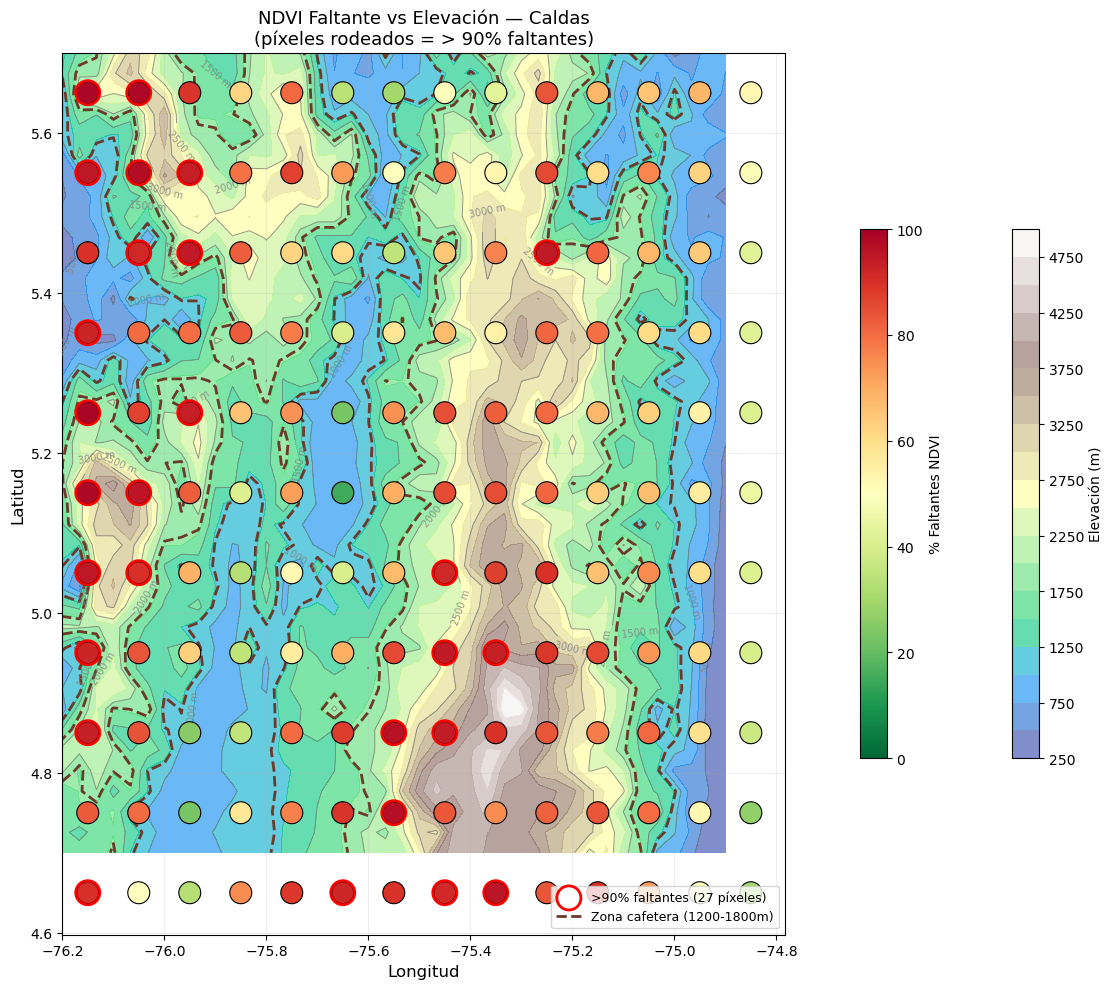

In [17]:
#  7.3 Mapa NDVI faltante vs Elevación 
fig, ax = plt.subplots(figsize=(12, 10))

# Fondo de relieve con curvas de nivel 
contourf = ax.contourf(
    lons_elev, lats_elev, elev_grid,
    levels=20,
    cmap='terrain',
    alpha=0.6
)
contour_lines = ax.contour(
    lons_elev, lats_elev, elev_grid,
    levels=[500, 1000, 1500, 2000, 2500, 3000],
    colors='gray',
    linewidths=0.7,
    alpha=0.8
)
ax.clabel(contour_lines, fmt='%d m', fontsize=7, colors='gray')
plt.colorbar(contourf, ax=ax, label='Elevación (m)', shrink=0.6, pad=0.01)

# Puntos de píxeles coloreados por % faltante NDVI 
scatter = ax.scatter(
    nulos_por_pixel["lon"],
    nulos_por_pixel["lat"],
    c=nulos_por_pixel["porcentaje_faltantes"],
    cmap="RdYlGn_r",
    s=250,
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
    vmin=0, vmax=100
)
plt.colorbar(scatter, ax=ax, label='% Faltantes NDVI', shrink=0.6, pad=0.08)

# Marcar píxeles con > 90% faltantes 
rojos = nulos_por_pixel[nulos_por_pixel["porcentaje_faltantes"] >= 90]
ax.scatter(
    rojos["lon"], rojos["lat"],
    s=300,
    facecolors='none',
    edgecolors='red',
    linewidths=2,
    zorder=6,
    label=f'>90% faltantes ({len(rojos)} píxeles)'
)

# Línea de altitud cafetera (1200 - 1800 msnm) 
ax.contour(
    lons_elev, lats_elev, elev_grid,
    levels=[1200, 1800],
    colors=['#6B3A2A'],
    linewidths=2,
    linestyles=['--', '--']
)
ax.plot([], [], '--', color='#6B3A2A', linewidth=2, label='Zona cafetera (1200-1800m)')

ax.set_xlabel("Longitud", fontsize=12)
ax.set_ylabel("Latitud", fontsize=12)
ax.set_title(
    "NDVI Faltante vs Elevación — Caldas\n(píxeles rodeados = > 90% faltantes)",
    fontsize=13
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('ndvi_faltantes_relieve_caldas.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# 7.4 Aplicar filtro al DataFrame principal
# Paso 1: filtrar por zona cafetera (elevación)
pixeles_validos = dentro[["lat", "lon"]].copy()
 
# Paso 2: de esos, excluir los que además tienen
# más del umbral de NDVI faltante
umbral = PARAMS["umbral_nulos_pixel"]
nulos_zona_cafetera = nulos_por_pixel[
    nulos_por_pixel[["lat", "lon"]]
    .apply(tuple, axis=1)
    .isin(pixeles_validos.apply(tuple, axis=1))
]
 
pixeles_validos = nulos_zona_cafetera[
    nulos_zona_cafetera["porcentaje_faltantes"] < umbral
][["lat", "lon"]].copy()
 
print(f"Píxeles en zona cafetera           : {len(dentro)}")
print(f"Píxeles excluidos por >{umbral}% NDVI nulo : "
      f"{len(dentro) - len(pixeles_validos)}")
print(f"Píxeles que pasan ambos filtros    : {len(pixeles_validos)}")
 
df_filtrado = df_final.merge(pixeles_validos, on=["lat", "lon"], how="inner")
 
print(f"\nShape antes del filtro  : {df_final.shape}")
print(f"Shape después del filtro: {df_filtrado.shape}")
print(f"NDVI faltante restante  : {df_filtrado['NDVI'].isna().mean()*100:.1f}%")

Píxeles en zona cafetera           : 83
Píxeles excluidos por >70% NDVI nulo : 34
Píxeles que pasan ambos filtros    : 49

Shape antes del filtro  : (81928, 15)
Shape después del filtro: (26068, 15)
NDVI faltante restante  : 52.6%


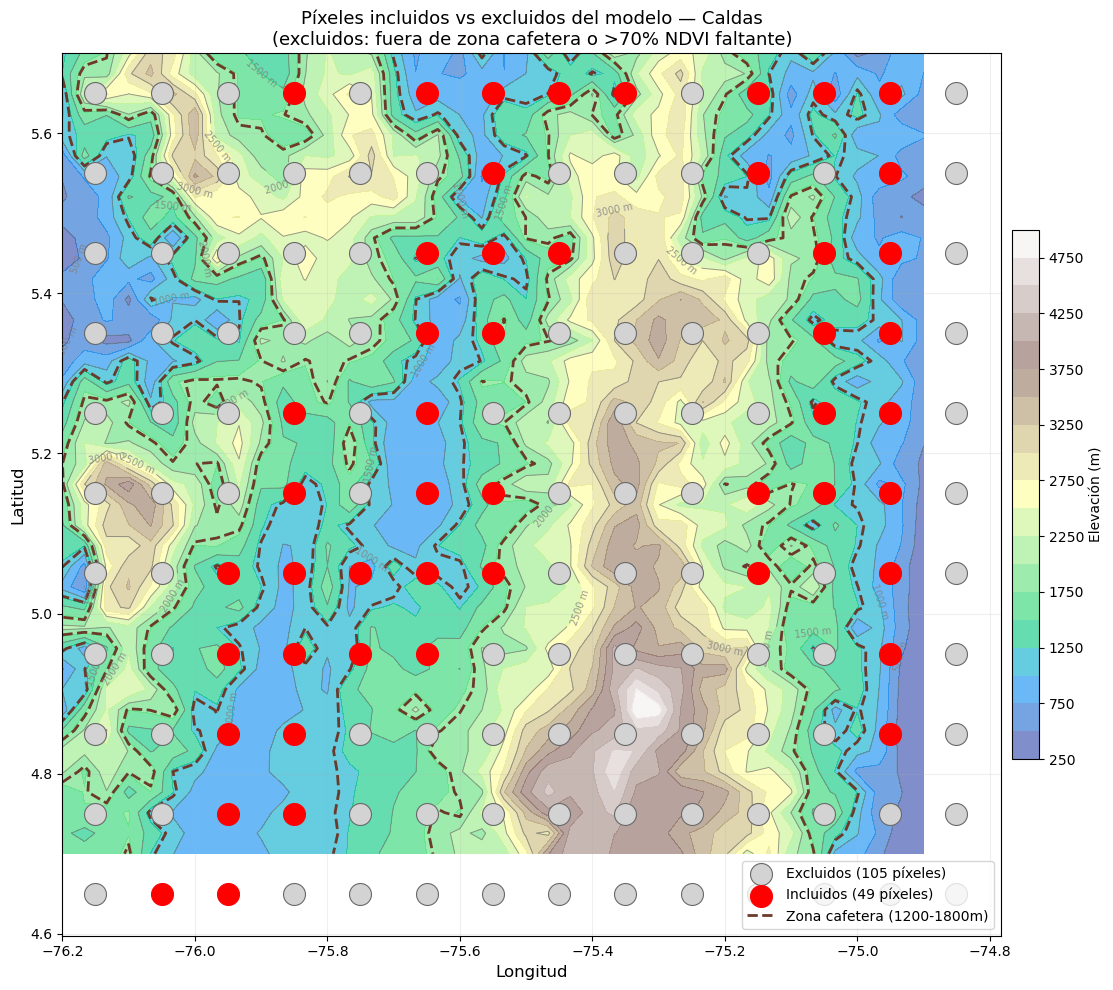

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

# ── 1. Fondo de relieve con curvas de nivel ───────────────────────────
contourf = ax.contourf(
    lons_elev, lats_elev, elev_grid,
    levels=20,
    cmap='terrain',
    alpha=0.6
)
contour_lines = ax.contour(
    lons_elev, lats_elev, elev_grid,
    levels=[500, 1000, 1500, 2000, 2500, 3000],
    colors='gray',
    linewidths=0.7,
    alpha=0.8
)
ax.clabel(contour_lines, fmt='%d m', fontsize=7, colors='gray')
plt.colorbar(contourf, ax=ax, label='Elevación (m)', shrink=0.6, pad=0.01)

# ── 2. Identificar píxeles incluidos vs excluidos ─────────────────────
todos = nulos_por_pixel[["lat", "lon"]].copy()

incluidos = pixeles_validos.copy()
incluidos["estado"] = "incluido"

excluidos = todos.merge(
    incluidos[["lat", "lon"]],
    on=["lat", "lon"],
    how="left",
    indicator=True
).query('_merge == "left_only"').drop(columns="_merge")
excluidos["estado"] = "excluido"

# ── 3. Píxeles EXCLUIDOS en gris ──────────────────────────────────────
ax.scatter(
    excluidos["lon"],
    excluidos["lat"],
    c="lightgray",
    s=250,
    edgecolors="dimgray",
    linewidths=0.8,
    zorder=5,
    label=f'Excluidos ({len(excluidos)} píxeles)'
)

# ── 4. Píxeles INCLUIDOS en verde ─────────────────────────────────────
ax.scatter(
    incluidos["lon"],
    incluidos["lat"],
    c="red",
    s=250,
    edgecolors="red",
    linewidths=0.8,
    zorder=6,
    label=f'Incluidos ({len(incluidos)} píxeles)'
)

# ── 5. Línea de zona cafetera (1200 - 1800 msnm) ──────────────────────
ax.contour(
    lons_elev, lats_elev, elev_grid,
    levels=[1200, 1800],
    colors=['#6B3A2A'],
    linewidths=2,
    linestyles=['--', '--']
)
ax.plot([], [], '--', color='#6B3A2A', linewidth=2, label='Zona cafetera (1200-1800m)')

# ── 6. Etiquetas y formato ────────────────────────────────────────────
ax.set_xlabel("Longitud", fontsize=12)
ax.set_ylabel("Latitud", fontsize=12)
ax.set_title(
    "Píxeles incluidos vs excluidos del modelo — Caldas\n"
    f"(excluidos: fuera de zona cafetera o >{PARAMS['umbral_nulos_pixel']}% NDVI faltante)",
    fontsize=13
)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pixeles_incluidos_excluidos_caldas.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print(f"Total píxeles (nulos_por_pixel) : {len(nulos_por_pixel)}")
print(f"Píxeles en zona cafetera        : {len(dentro)}")
print(f"Píxeles válidos finales         : {len(pixeles_validos)}")
print(f"Píxeles excluidos mi código     : {154 - len(pixeles_validos)}")

# Ver cuántos excluye cada criterio por separado
excluidos_por_elevacion = 154 - len(dentro)
excluidos_por_ndvi      = len(dentro) - len(pixeles_validos)

print(f"\nExcluidos por elevación         : {excluidos_por_elevacion}")
print(f"Excluidos por NDVI faltante     : {excluidos_por_ndvi}")

Total píxeles (nulos_por_pixel) : 154
Píxeles en zona cafetera        : 83
Píxeles válidos finales         : 49
Píxeles excluidos mi código     : 105

Excluidos por elevación         : 71
Excluidos por NDVI faltante     : 34


## 8. Split temporal — Train / Val / Test
Definición temporal según `PARAMS` (equivalente a `params.yaml`):

| Partición | Período |
|-----------|---------|
| **Train** | inicio → 2018-12-31 |
| **Val**   | 2019-01-01 → 2021-12-31 |
| **Test**  | 2022-01-01 → fin |


> El split es **estrictamente temporal** (sin shuffle) para evitar data leakage.


In [21]:
# 8.1 Crear particiones 
train_end  = pd.Timestamp(PARAMS["train_end"])
val_start  = pd.Timestamp(PARAMS["val_start"])
val_end    = pd.Timestamp(PARAMS["val_end"])
test_start = pd.Timestamp(PARAMS["test_start"])

df_train = df_filtrado[df_filtrado["fecha"] <= train_end].copy()
df_val   = df_filtrado[(df_filtrado["fecha"] >= val_start) & (df_filtrado["fecha"] <= val_end)].copy()
df_test  = df_filtrado[df_filtrado["fecha"] >= test_start].copy()

for nombre, df_part in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    print(f"{'─'*50}")
    print(f"  {nombre}")
    print(f"  Fechas : {df_part['fecha'].min().date()} → {df_part['fecha'].max().date()}")
    print(f"  Filas  : {len(df_part):,}")
    print(f"  % total: {len(df_part)/len(df_filtrado)*100:.1f}%")
    print(f"  NDVI faltante: {df_part['NDVI'].isna().mean()*100:.1f}%")
print(f"{'─'*50}")


──────────────────────────────────────────────────
  TRAIN
  Fechas : 2003-01-01 → 2018-12-28
  Filas  : 17,934
  % total: 68.8%
  NDVI faltante: 50.8%
──────────────────────────────────────────────────
  VAL
  Fechas : 2019-01-13 → 2021-12-20
  Filas  : 3,332
  % total: 12.8%
  NDVI faltante: 57.3%
──────────────────────────────────────────────────
  TEST
  Fechas : 2022-01-05 → 2026-04-06
  Filas  : 4,802
  % total: 18.4%
  NDVI faltante: 56.3%
──────────────────────────────────────────────────


In [22]:
# 8.2 Verificar cobertura de extremos NDVI en cada partición 
# El seguro indexado depende de capturar bien los extremos (sequías, excesos)
# → verificamos que los percentiles extremos estén bien representados

print("=== COBERTURA DE EXTREMOS NDVI POR PARTICIÓN ===\n")

p5  = df_filtrado["NDVI"].quantile(0.05)
p95 = df_filtrado["NDVI"].quantile(0.95)
print(f"Percentil  5 global (NDVI bajo / estrés)  : {p5:.4f}")
print(f"Percentil 95 global (NDVI alto / salud)   : {p95:.4f}\n")

for nombre, df_part in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    ndvi = df_part["NDVI"].dropna()
    n_bajo  = (ndvi <= p5).sum()
    n_alto  = (ndvi >= p95).sum()
    print(f"  {nombre:<6} | p5 obs: {ndvi.quantile(0.05):.4f} | p95 obs: {ndvi.quantile(0.95):.4f} "
          f"| extremos bajos: {n_bajo} | extremos altos: {n_alto}")

print()
print("✅ Si los extremos bajos/altos están presentes en val y test,")
print("   el modelo puede evaluarse sobre condiciones de estrés reales.")


=== COBERTURA DE EXTREMOS NDVI POR PARTICIÓN ===

Percentil  5 global (NDVI bajo / estrés)  : 0.6546
Percentil 95 global (NDVI alto / salud)   : 0.8330

  TRAIN  | p5 obs: 0.6474 | p95 obs: 0.8306 | extremos bajos: 487 | extremos altos: 381
  VAL    | p5 obs: 0.6613 | p95 obs: 0.8415 | extremos bajos: 63 | extremos altos: 110
  TEST   | p5 obs: 0.6773 | p95 obs: 0.8355 | extremos bajos: 68 | extremos altos: 127

✅ Si los extremos bajos/altos están presentes en val y test,
   el modelo puede evaluarse sobre condiciones de estrés reales.


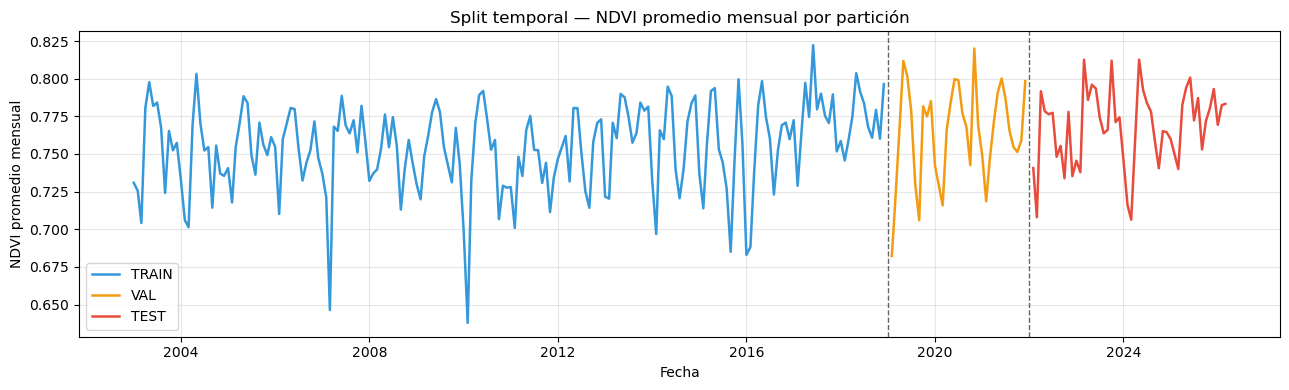

In [23]:
# 8.3 Visualización del split temporal 
ndvi_mensual = (
    df_filtrado.dropna(subset=["NDVI"])
    .assign(mes=df_filtrado["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")["NDVI"]
    .mean()
    .reset_index()
)

colores = {"TRAIN": "#3498DB", "VAL": "#F39C12", "TEST": "#E74C3C"}

fig, ax = plt.subplots(figsize=(13, 4))
for nombre, df_part in [("TRAIN", df_train), ("VAL", df_val), ("TEST", df_test)]:
    mask = (ndvi_mensual["mes"] >= df_part["fecha"].min()) &            (ndvi_mensual["mes"] <= df_part["fecha"].max())
    ax.plot(ndvi_mensual.loc[mask, "mes"],
            ndvi_mensual.loc[mask, "NDVI"],
            color=colores[nombre], linewidth=1.8, label=nombre)

ax.axvline(train_end,  color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.axvline(val_end,    color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Fecha"); ax.set_ylabel("NDVI promedio mensual")
ax.set_title("Split temporal — NDVI promedio mensual por partición")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8b. Feature Engineering
Variables derivadas calculadas sobre los splits **después** del split temporal.

| Variable | Descripción | Unidad |
|---|---|---|
| `BAL` | Balance hídrico = ppt×1000 − pet (ppt_mm es temporal, no se guarda) | mm/16d |
| `Z_{var}` | Anomalía Z por DOY para las 10 variables del modelo | z-score |
| `NDVI_anom` | Anomalía Z del NDVI por DOY (proxy de pérdida agrícola) | z-score |

**Regla crítica — evitar data leakage:**  
Los parámetros μ_DOY y σ_DOY se estiman **exclusivamente sobre `df_train`**  
y se aplican sin reajuste a `df_val` y `df_test`.

In [24]:
# =====================================================================
# 8b.1  BAL — Balance hídrico
# =====================================================================

for df in [df_train, df_val, df_test]:
    df['BAL'] = df['ppt'] * 1000 - df['pet']

print("BAL generado:")
print(f"  TRAIN — rango: {df_train['BAL'].min():.1f}  a  {df_train['BAL'].max():.1f} mm/16d")
print(f"  VAL   — rango: {df_val['BAL'].min():.1f}    a  {df_val['BAL'].max():.1f} mm/16d")
print(f"  TEST  — rango: {df_test['BAL'].min():.1f}   a  {df_test['BAL'].max():.1f} mm/16d")

# =====================================================================
# 8b.2 + 8b.3  Anomalías Z por PERÍODO — variables climáticas y NDVI
#
# Se usa periodo_en_año() en lugar de dt.dayofyear para evitar
# fragmentación por años bisiestos (54 DOYs con < 5 obs. en versión anterior).
# periodo_en_año() produce exactamente 23 períodos únicos (0–22).
#
# PROTECCIÓN CONTRA RE-EJECUCIÓN:
# Al inicio se eliminan columnas creadas en ejecuciones anteriores
# para evitar duplicados que causen errores en los prints de verificación.
# =====================================================================

VARS_MODELO = [
    'tmax', 'tmin', 'skin_temp', 'ppt', 'srad',
    'pet', 'soil_water', 'vap', 'vpd', 'ws', 'BAL'
]

# ── Limpiar columnas previas (protección ante re-ejecución) ───────────
cols_a_limpiar = (
    ['NDVI_anom', 'Z_NDVI', 'periodo'] +
    [f'Z_{v}' for v in VARS_MODELO]
)
for df in [df_train, df_val, df_test]:
    cols_existentes = [c for c in cols_a_limpiar if c in df.columns]
    if cols_existentes:
        df.drop(columns=cols_existentes, inplace=True)

# ── Función auxiliar ───────────────────────────────────────────────────

def periodo_en_año(fecha):
    """
    Índice del período de 16 días dentro del año (0 a 22).
    Invariante ante años bisiestos.
    """
    inicio_año = fecha.apply(lambda d: d.replace(month=1, day=1))
    dias_desde_inicio = (fecha - inicio_año).dt.days
    return (dias_desde_inicio // 16).astype(int)


# ── Funciones de normalización ─────────────────────────────────────────

def calcular_params_doy(df, variables):
    """
    Calcula μ_periodo y σ_periodo para cada variable.
    Solo debe llamarse sobre df_train.
    """
    df = df.copy()
    df['periodo'] = periodo_en_año(df['fecha'])
    params = {}
    for var in variables:
        stats = (
            df.dropna(subset=[var])
            .groupby('periodo')[var]
            .agg(mu='mean', sigma='std', n='count')
            .reset_index()
        )
        params[var] = stats
    return params


def apply_z_scores(df, params, suffix='Z'):
    """
    Aplica normalización Z por período usando parámetros de train.
    Retorna copia del DataFrame con columnas Z_ añadidas.
    """
    df = df.copy()
    df['periodo'] = periodo_en_año(df['fecha'])
    for var, stats in params.items():
        stats_idx = stats.set_index('periodo')
        mu_map    = df['periodo'].map(stats_idx['mu'])
        sigma_map = df['periodo'].map(stats_idx['sigma'])
        df[f'{suffix}_{var}'] = (
            (df[var] - mu_map) / sigma_map.replace(0, np.nan)
        )
    return df


# ── Parámetros SOLO desde train ────────────────────────────────────────

params_climaticas = calcular_params_doy(df_train, VARS_MODELO)
params_ndvi       = calcular_params_doy(
    df_train.dropna(subset=['NDVI']), ['NDVI']
)

# Verificar períodos únicos y observaciones por período
n_periodos = df_train['fecha'].apply(
    lambda d: (d - d.replace(month=1,day=1)).days // 16
).nunique()
print(f"Períodos únicos en train: {n_periodos} (esperado: 23)")
print(f"Parámetros calculados sobre df_train ({len(df_train):,} registros)")

n_obs_periodo = params_ndvi['NDVI'].set_index('periodo')['n']
periodos_escasos = n_obs_periodo[n_obs_periodo < 5]
if len(periodos_escasos) > 0:
    print(f"\n⚠️  {len(periodos_escasos)} períodos con < 5 obs. NDVI en TRAIN:")
    print(periodos_escasos.to_string())
else:
    print(f"\n✅ Todos los períodos tienen >= 5 observaciones NDVI en TRAIN")
    print(f"   Mínimo: {n_obs_periodo.min()} | Máximo: {n_obs_periodo.max()}")

# ── Aplicar a los tres splits ──────────────────────────────────────────

df_train = apply_z_scores(df_train, params_climaticas)
df_val   = apply_z_scores(df_val,   params_climaticas)
df_test  = apply_z_scores(df_test,  params_climaticas)

df_train = apply_z_scores(df_train, params_ndvi)
df_val   = apply_z_scores(df_val,   params_ndvi)
df_test  = apply_z_scores(df_test,  params_ndvi)

# Renombrar Z_NDVI → NDVI_anom
for df in [df_train, df_val, df_test]:
    df.rename(columns={'Z_NDVI': 'NDVI_anom'}, inplace=True)

# ── Verificación ──────────────────────────────────────────────────────

cols_z = [f'Z_{v}' for v in VARS_MODELO]

print("\nVerificación en TRAIN (esperado: media ≈ 0, std ≈ 1):")
print(f"  Media promedio Z climáticas : {df_train[cols_z].mean().mean():.4f}")
print(f"  Std promedio Z climáticas   : {df_train[cols_z].std().mean():.4f}")

train_ndvi_anom = df_train['NDVI_anom'].dropna()
print(f"\n  NDVI_anom en TRAIN:")
print(f"    Obs. válidas : {len(train_ndvi_anom):,}")
print(f"    Media        : {train_ndvi_anom.mean():.4f}  (esperado ≈ 0)")
print(f"    Std          : {train_ndvi_anom.std():.4f}  (esperado ≈ 1)")

# Diagnóstico: NDVI válido vs NDVI_anom válido
print("\n=== DIAGNÓSTICO — NDVI válido vs NDVI_anom válido ===")
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    ndvi_ok      = df['NDVI'].notna().sum()
    ndvi_anom_ok = df['NDVI_anom'].notna().sum()
    perdidos     = ndvi_ok - ndvi_anom_ok
    pct = perdidos / ndvi_ok * 100 if ndvi_ok > 0 else 0
    print(f"  {nombre}: NDVI válido={ndvi_ok:,} | "
          f"NDVI_anom válido={ndvi_anom_ok:,} | "
          f"perdidos={perdidos:,} ({pct:.1f}%)")
print("  → Si 'perdidos' ≈ 0, la corrección de períodos funcionó correctamente.")


BAL generado:
  TRAIN — rango: -74.4  a  1729.6 mm/16d
  VAL   — rango: -76.3    a  1744.2 mm/16d
  TEST  — rango: -73.5   a  1868.0 mm/16d
Períodos únicos en train: 23 (esperado: 23)
Parámetros calculados sobre df_train (17,934 registros)

✅ Todos los períodos tienen >= 5 observaciones NDVI en TRAIN
   Mínimo: 193 | Máximo: 678

Verificación en TRAIN (esperado: media ≈ 0, std ≈ 1):
  Media promedio Z climáticas : 0.0000
  Std promedio Z climáticas   : 0.9994

  NDVI_anom en TRAIN:
    Obs. válidas : 8,829
    Media        : -0.0000  (esperado ≈ 0)
    Std          : 0.9988  (esperado ≈ 1)

=== DIAGNÓSTICO — NDVI válido vs NDVI_anom válido ===
  TRAIN: NDVI válido=8,829 | NDVI_anom válido=8,829 | perdidos=0 (0.0%)
  VAL: NDVI válido=1,423 | NDVI_anom válido=1,423 | perdidos=0 (0.0%)
  TEST: NDVI válido=2,097 | NDVI_anom válido=2,097 | perdidos=0 (0.0%)
  → Si 'perdidos' ≈ 0, la corrección de períodos funcionó correctamente.


In [25]:
# =====================================================================
# 8b.4  Guardar parámetros de normalización
#
# scaler_params.pkl contiene μ_DOY y σ_DOY de cada variable.
# Se usará en el API para normalizar nuevas observaciones antes
# de pasarlas al modelo IC, garantizando reproducibilidad.
# =====================================================================

import pickle

params_export = {
    var: stats.to_dict(orient='records')
    for var, stats in params_climaticas.items()
}
params_export['NDVI'] = (
    params_ndvi['NDVI'].to_dict(orient='records')
)

os.makedirs('output', exist_ok=True)
with open('output/scaler_params.pkl', 'wb') as f:
    pickle.dump(params_export, f)

# Resumen de columnas disponibles para los modelos
cols_modelo = ['fecha', 'lat', 'lon', 'DOY',
               'NDVI', 'NDVI_anom', 'BAL'] + VARS_MODELO + cols_z

print(f"{'Columna':<22} {'Tipo':<12} {'NaN':>8}")
print("-" * 44)
for c in cols_modelo:
    if c in df_train.columns:
        dtype = str(df_train[c].dtype)
        n_na  = df_train[c].isna().sum()
        print(f"  {c:<20} {dtype:<12} {n_na:>8,}")

print(f"\n✅ scaler_params.pkl guardado en output/")
print(f"✅ df_train, df_val, df_test listos con todas las variables")

Columna                Tipo              NaN
--------------------------------------------
  fecha                datetime64[us]        0
  lat                  float64             0
  lon                  float64             0
  NDVI                 float64         9,105
  NDVI_anom            float64         9,105
  BAL                  float64             0
  tmax                 float64             0
  tmin                 float64             0
  skin_temp            float64             0
  ppt                  float64             0
  srad                 float64             0
  pet                  float64             0
  soil_water           float64             0
  vap                  float64             0
  vpd                  float64             0
  ws                   float64             0
  BAL                  float64             0
  Z_tmax               float64             0
  Z_tmin               float64             0
  Z_skin_temp          float64             0
  Z_ppt 

## 9. Exportación

In [ ]:
os.makedirs("../output", exist_ok=True)

df_train.to_parquet("../output/df_train.parquet", index=False)
df_val.to_parquet("../output/df_val.parquet",   index=False)
df_test.to_parquet("../output/df_test.parquet",  index=False)
df_filtrado.to_parquet("../output/df_filtrado_completo.parquet", index=False)

# Guardar parámetros del split como params.yaml
import yaml
with open("../output/params.yaml", "w") as f:
    yaml.dump(PARAMS, f, default_flow_style=False, allow_unicode=True)

print("✅ Archivos exportados en output/:")
for f in sorted(os.listdir("../output")):
    size = os.path.getsize(f"../output/{f}") / 1024
    print(f"   {f:<45} {size:>8.1f} KB")


✅ Archivos exportados en output/:
   df_filtrado_completo.parquet                    2197.1 KB
   df_test.parquet                                  963.3 KB
   df_train.parquet                                3668.1 KB
   df_val.parquet                                   663.8 KB
   params.yaml                                        0.2 KB
   scaler_params.pkl                                 10.4 KB
